# How the Allen Visual Coding Neuropixels spreadsheet is measured

1. **What is in Allen VCN?** The two session types, the files, and what we kept.
2. **From that, how do we get the spreadsheet numbers?** Subjects, trials, neurons, length, sizes.
3. **Figures.** Stimuli, session timeline, neurons, firing rates, trials by stimulus, conditions × repeats, trials per session, regions, raster.
4. **Which sessions the draft uses.**

The data lives on HAL (`~/ismael/allen/data`, 146.2 GB, everything in the public bucket except LFP).
`data/allen/allen_extract.py` reduced it there to the small tables in `data/allen/tables/` (22 MB), which this
notebook reads.

## 1. What is in Allen VCN

- **Visual Coding – Neuropixels** (Siegle et al. 2021): **58 sessions, 58 mice** (one session per mouse),
  up to 6 Neuropixels 1.0 probes per session through visual cortex, hippocampus and thalamus. Head-fixed,
  passive viewing, running on a wheel. Released on S3 as `s3://allen-brain-observatory/visual-coding-neuropixels/ecephys-cache/`.
- **Two session types, different stimulus sets:**
  - **Brain Observatory 1.1 (BO), 32 sessions.** Gabors, flashes, drifting gratings (8 directions × 5 temporal
    frequencies), static gratings, 118 natural scenes, natural movies one and three. 8 of the 32 sessions
    also show drifting gratings × contrast.
  - **Functional Connectivity (FC), 26 sessions.** Gabors, flashes, dot motion, drifting gratings at one TF
    with 75 repeats, drifting gratings × contrast, and natural movie one with more repeats plus a shuffled version.
    FC trades stimulus variety for more repeats.
- **Spike sorting:** Kilosort2. Each NWB holds every unit, including artifacts labeled `quality == 'noise'`;
  the rest are labeled `'good'`, which only means not noise, not that they pass QC. AllenSDK's default unit
  QC (used here as **QC units**) is not noise & ISI violations < 0.5 & amplitude cutoff < 0.1 &
  presence ratio > 0.9.

**Allen terms, briefly**

- **Allen Brain Observatory vs Allen Brain Atlas.** The *Observatory* is the recording project this data comes
  from. The *Atlas* (Common Coordinate Framework, CCF v3) is the Allen Institute's 3D reference mouse brain;
  each probe's track is registered to it, and that is where the region labels (VISp, CA1, LGd, ...) come from.
  IBL uses the same atlas.
- **"Functional Connectivity" is only the name of a stimulus protocol.** It shows fewer stimulus types with many
  more repeats, which is what estimating correlations and interactions between simultaneously recorded neurons
  needs. It has nothing to do with fMRI functional connectivity, and no connectivity data is shipped. The
  recordings are the same kind as BO: Neuropixels spikes during passive viewing.
- **ISI violations / amplitude cutoff / presence ratio** — the three QC metrics. ISI violations estimates the
  fraction of spikes from other neurons (spikes closer than the refractory period); amplitude cutoff estimates the
  fraction of the unit's spikes missed because they fell below the detection threshold; presence ratio is the
  fraction of the session in which the unit fires at all (it catches units that drift away).
- **Opto-tagging** — the Cre;Ai32 mice express channelrhodopsin in one cell type; light pulses at the end of the
  session make those neurons fire, so they can be identified. Those pulses are not counted as trials.

**What the bucket holds, and what we kept** (sizes from the S3 listing):

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

here = Path.cwd().resolve()
REPO = here
for candidate in [here, *here.parents]:
    if (candidate / "src" / "ladys").is_dir() or (candidate / "data" / "allen" / "tables").exists():
        REPO = candidate
        break
TABLES = REPO / "data" / "allen" / "tables"
FIGURE_DIR = REPO / "tutorials" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
assert TABLES.exists(), f"Expected extracted tables at {TABLES}; see data/allen/README.md"
GB = 1e9
BO, FC = "brain_observatory_1.1", "functional_connectivity"
SHORT = {BO: "BO", FC: "FC"}
TYPE_COLOR = {BO: "C0", FC: "C1"}

sessions = pd.read_parquet(TABLES / "sessions.parquet")
units = pd.read_parquet(TABLES / "units.parquet")
stimuli = pd.read_parquet(TABLES / "stimuli.parquet")
bucket = pd.read_csv(TABLES / "bucket_files.csv")
storage = pd.read_csv(TABLES / "nwb_storage.csv")

session_type = sessions.set_index("session_id").session_type
units["type"] = units.session_id.map(session_type)
units["noise"] = units.quality == "noise"
stimuli["type"] = stimuli.session_id.map(session_type)
bucket["type"] = bucket.session_id.map(session_type)

files = {
    "session_nwb": ("session_<id>.nwb: spikes, units, stimulus tables, running, eye tracking", "kept"),
    "session_metrics": ("session_<id>_analysis_metrics.csv: per-unit tuning metrics", "kept"),
    "lfp": ("probe_<id>_lfp.nwb: 1250 Hz LFP per probe", "ditched"),
    "templates": ("natural scene images + natural movie frames", "kept"),
    "metadata": ("sessions / probes / channels / units CSVs, manifest", "kept"),
}
display(pd.DataFrame([
    {"files": k, "what": w, "count": int((bucket.kind == k).sum()),
     "GB": round(bucket.bytes[bucket.kind == k].sum() / GB, 2), "kept?": kept}
    for k, (w, kept) in files.items()
]))
print(f"whole bucket: {bucket.bytes.sum() / GB:,.2f} GB; kept: {bucket.bytes[bucket.kind != 'lfp'].sum() / GB:,.2f} GB")

,files,what,count,GB,kept?
0,session_nwb,"session_<id>.nwb: spikes, units, stimulus tables, running, eye tracking",58,144.97,kept
1,session_metrics,session_<id>_analysis_metrics.csv: per-unit tuning metrics,58,0.08,kept
2,lfp,probe_<id>_lfp.nwb: 1250 Hz LFP per probe,325,707.55,ditched
3,templates,natural scene images + natural movie frames,120,0.96,kept
4,metadata,"sessions / probes / channels / units CSVs, manifest",7,0.14,kept


whole bucket: 853.71 GB; kept: 146.15 GB


There is no raw 30 kHz voltage in the bucket; spikes are the rawest public form besides LFP.

**Inside the session NWBs** (HDF5 storage, summed over the 58 files): more than half is per-spike amplitudes and
mean waveforms, neither of which a spiking benchmark needs.

In [2]:
nwb = storage.drop(columns="session_id").sum() / GB
display(nwb.round(2).rename("GB").to_frame().T)

,spike_times,spike_amplitudes,waveform_mean,other
GB,51.17,51.17,34.4,7.44


In [3]:
checks = {
    "sessions": (len(sessions), 58),
    "BO sessions": (int((sessions.session_type == BO).sum()), 32),
    "FC sessions": (int((sessions.session_type == FC).sum()), 26),
    "mice": (sessions.specimen_id.nunique(), 58),
    "QC units (AllenSDK default)": (int(units.qc.sum()), 41_552),
}
display(pd.DataFrame(checks, index=["measured", "expected"]).T)
for name, (measured, expected) in checks.items():
    assert measured == expected, name
assert sessions.units.sum() == len(units)
assert set(units.quality) == {"good", "noise"}
print(f"units in NWBs: {len(units):,}, of which {units.noise.sum():,} are labeled noise (artifacts, not neurons)")
print("(the cache's units.csv lists 135,275; the NWBs hold 1,281 more, and the NWBs are what is counted)")

,measured,expected
sessions,58,58
BO sessions,32,32
FC sessions,26,26
mice,58,58
QC units (AllenSDK default),41552,41552


units in NWBs: 136,556, of which 36,712 are labeled noise (artifacts, not neurons)
(the cache's units.csv lists 135,275; the NWBs hold 1,281 more, and the NWBs are what is counted)


## 2. How those files become spreadsheet numbers

One totals row per session type, because BO and FC show different stimuli, then one row per stimulus
(see Spreadsheet at the end).

- **SUBJECTS**: mice (`specimen_id`). One session per mouse.
- **TRIALS**: stimulus presentations, i.e. rows of the NWB `*_presentations` tables. Natural movies are
  counted per repeat (a 30 s movie is one trial, not 900 frames). Spontaneous blocks are not trials.
  One BO gabor, static grating or natural scene lasts 250 ms, so these dominate the count.
- **NEURONS**: QC units (AllenSDK default filter). The draft's Allen splits appear to use a subset of these (section 4).
  TOTAL = sum and MEDIAN = per session, rounded half up (all probes of a session are simultaneous). All-unit counts go in NOTES.
- **CHANNELS**: `N/A` (sorted units).
- **LENGTH**: per session, first to last spike, summed over sessions.
- **RAW**: everything the bucket holds for these sessions: session NWBs, per-probe LFP NWBs and unit metric CSVs.
- **BENCHMARK**: a QC-units build. It keeps spike times of QC units only (8 bytes per spike, as stored) plus
  the NWB's non-spike datasets (stimulus tables, unit metadata, running, eye tracking) and the metric CSVs.
  It also keeps the stimulus templates the type shows. Per-spike amplitudes and mean waveforms are dropped.
  Natural movie one (0.17 GB) is shown in both types and is counted in both rows. Shared metadata CSVs
  (0.14 GB) are left out.
- **BASIC STATS**: one firing rate per QC unit, from the NWB `firing_rate` column (whole-session rate).

Per-session table:

In [4]:
trial_stims = stimuli[stimuli.stimulus != "spontaneous"]
sessions["trials"] = sessions.session_id.map(trial_stims.groupby("session_id").size())
sessions["recording_min"] = sessions.recording_s / 60
sessions["stimulus_min"] = sessions.stimulus_s / 60
sessions = sessions.sort_values(["session_type", "trials", "units"], ignore_index=True)
cols = ["probes", "units", "qc_units", "trials", "recording_min", "stimulus_min", "age_days"]
display(sessions.groupby("session_type")[cols].agg(["min", "median", "max"]).T.unstack(0).round(1))
display(sessions.genotype.value_counts().rename("sessions").to_frame())

session_type brain_observatory_1.1                                                               functional_connectivity                           \
                            probes   units qc_units   trials recording_min stimulus_min age_days                  probes   units qc_units  trials   
min                            4.0  1603.0    452.0  16403.0         154.5        152.0     91.0                     5.0  1478.0    429.0  5435.0   
median                         6.0  2292.0    681.5  16405.0         161.4        152.1    110.0                     6.0  2495.5    736.0  5435.0   
max                            6.0  3232.0    984.0  16945.0         178.0        161.6    141.0                     6.0  3071.0   1036.0  5510.0   

session_type                                      
             recording_min stimulus_min age_days  
min                  160.4        152.1    108.0  
median               164.0        152.1    121.5  
max                  178.5        154.6    142.0

,sessions
genotype,
wt/wt,30
Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,12
Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,8
Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,8


## 3. Figures

### Stimuli: what the mouse sees

Every session opens with gabors and flashes, then plays one of two fixed programs, BO or FC. One tile per
stimulus: what changes from trial to trial, trial length and repeats, and what the stimulus probes (→). Photos
and movie frames are the real stimuli (`TABLES / "stim_samples"`: 4 of the 118 natural scenes and 6 frames of
natural movie one, see `data/allen/README.md`); gratings, patches, flashes and dots are drawn from the stimulus
parameters (schematic, not to scale). Conditions and durations come from `stimuli` and the technical whitepaper
(pp. 17–18).

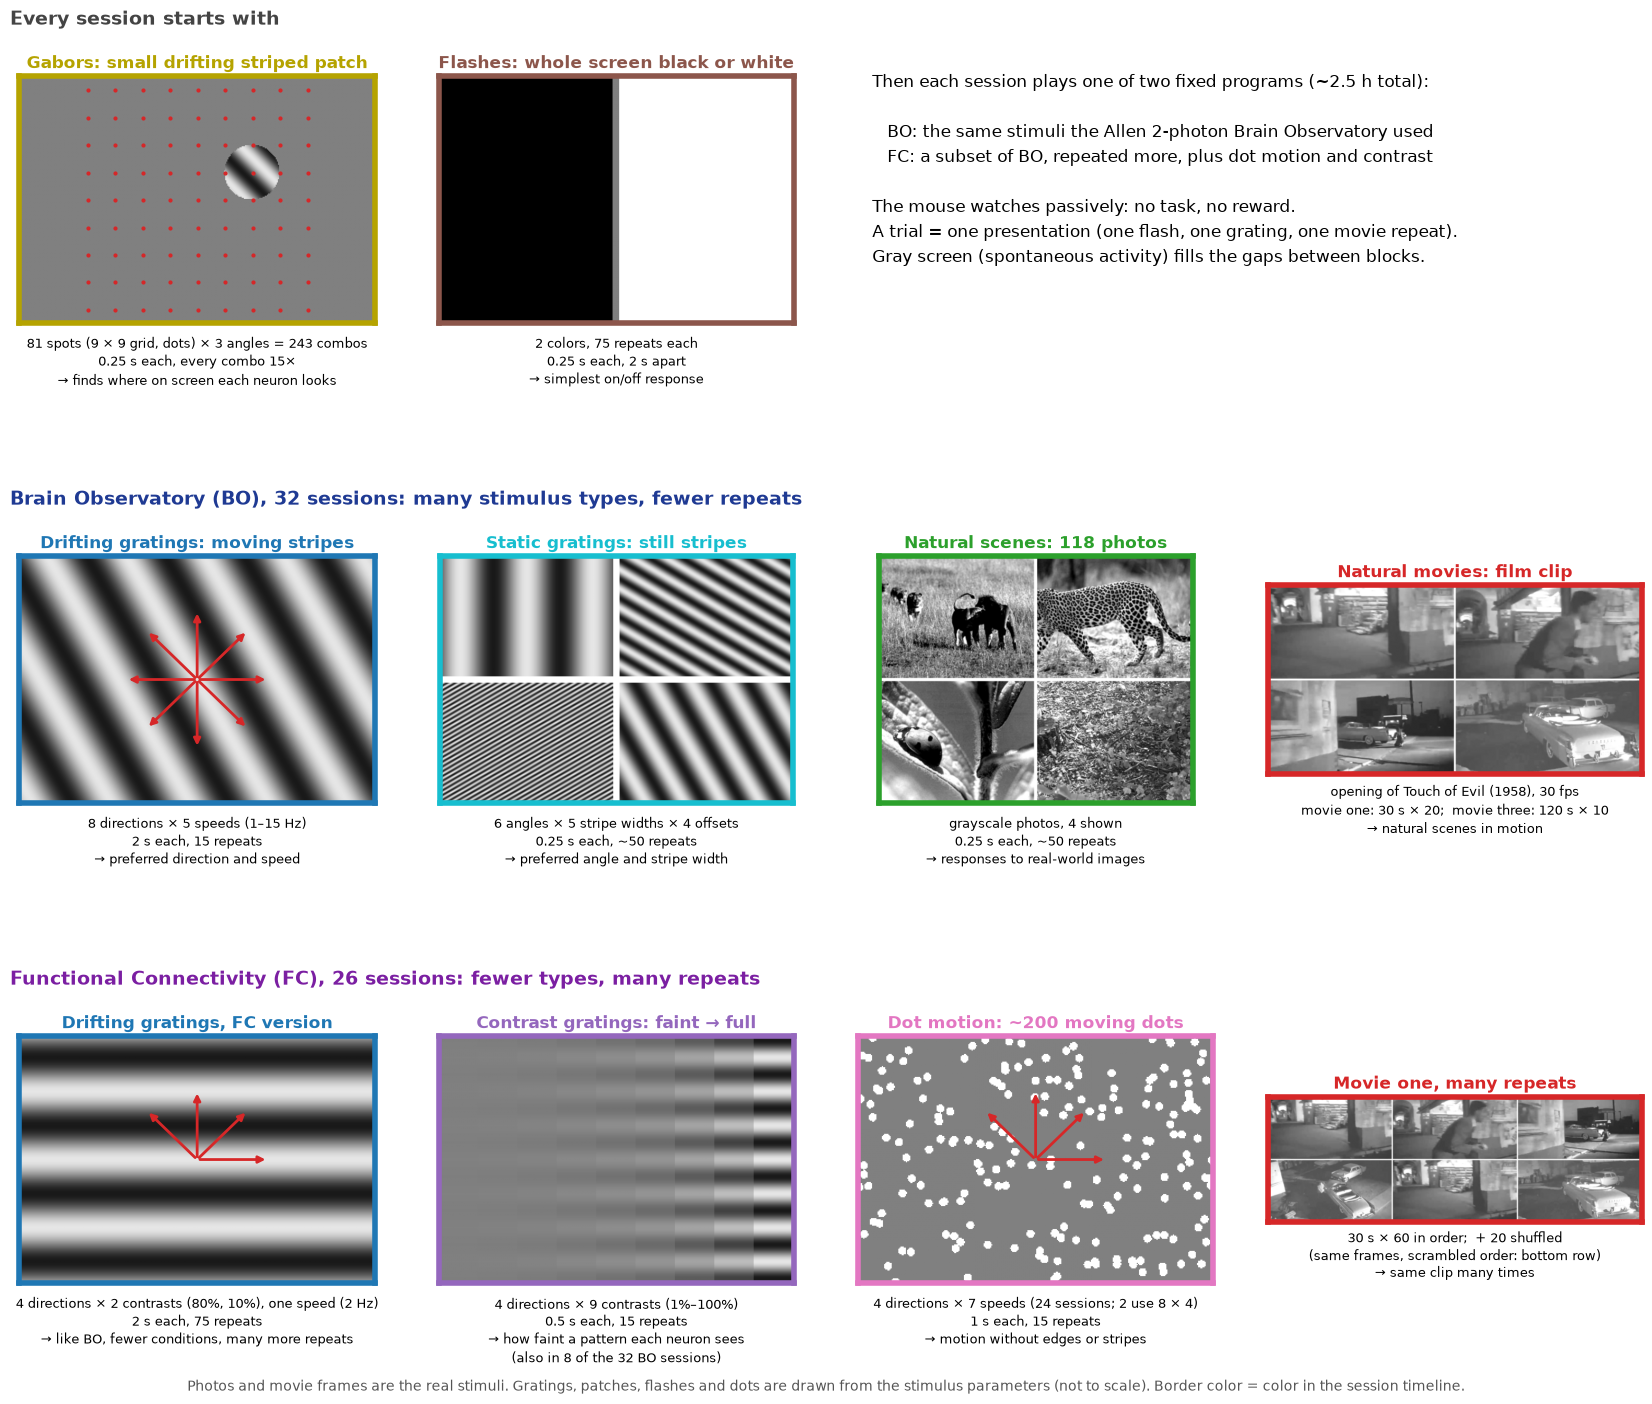

In [5]:
from PIL import Image

SAMPLES = TABLES / "stim_samples"
STIM_COLOR = {
    "gabors": "#b5a300", "flashes": "#8c564b", "drifting_gratings": "#1f77b4", "static_gratings": "#17becf",
    "natural_scenes": "#2ca02c", "natural_movie_one": "#d62728", "natural_movie_three": "#ff7f0e",
    "drifting_gratings_contrast": "#9467bd", "dot_motion": "#e377c2", "natural_movie_one_shuffled": "#f4a6a6",
    "spontaneous": "#d9d9d9",
}
# FC variants of a BO stimulus share its color
STIM_COLOR["drifting_gratings_75_repeats"] = STIM_COLOR["drifting_gratings"]
STIM_COLOR["natural_movie_one_more_repeats"] = STIM_COLOR["natural_movie_one"]

# Schematic screen: 130 x 90 degrees of visual angle at 2.5 px/deg
W, H = 325, 225
SX, SY = np.meshgrid(np.linspace(-65, 65, W), np.linspace(45, -45, H))


def grating(ori_deg, sf=0.04, contrast=0.8, phase=0.0):
    t = np.deg2rad(ori_deg)
    return 0.5 + 0.5 * contrast * np.cos(2 * np.pi * sf * (SX * np.cos(t) + SY * np.sin(t)) + phase)


def mosaic(images, ncols, pad=6):
    h, w = images[0].shape
    nrows = int(np.ceil(len(images) / ncols))
    out = np.ones((nrows * h + (nrows - 1) * pad, ncols * w + (ncols - 1) * pad))
    for i, im in enumerate(images):
        r, c = divmod(i, ncols)
        out[r * (h + pad): r * (h + pad) + h, c * (w + pad): c * (w + pad) + w] = im
    return out


def direction_arrows(ax, angles):
    for a in np.deg2rad(angles):
        ax.annotate("", xy=(0.5 + 0.2 * np.cos(a), 0.5 + 0.28 * np.sin(a)), xytext=(0.5, 0.5),
                    xycoords="axes fraction", arrowprops=dict(arrowstyle="-|>", color="C3", lw=2))


def stim_tile(ax, img, key, title, lines):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="bilinear")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color(STIM_COLOR[key])
        s.set_linewidth(4)
    ax.set_title(title, fontsize=12, fontweight="bold", color=STIM_COLOR[key], pad=6)
    ax.text(0.5, -0.05, "\n".join(lines), transform=ax.transAxes, ha="center", va="top", fontsize=9.5,
            linespacing=1.35)


gabor = np.full((H, W), 0.5)
patch = (SX - 20) ** 2 + (SY - 10) ** 2 < 10 ** 2  # 20 deg circular mask
gabor[patch] = grating(45, sf=0.08)[patch]
flash = np.zeros((H, W))
flash[:, W // 2:] = 1
flash[:, W // 2 - 3: W // 2 + 3] = 0.5
dots = np.full((H, W), 0.5)
rng = np.random.default_rng(0)
for x, y in zip(rng.uniform(-65, 65, 200), rng.uniform(-45, 45, 200)):
    dots[(SX - x) ** 2 + (SY - y) ** 2 < 1.5 ** 2] = 1.0
contrasts = np.array([0.01, 0.02, 0.04, 0.08, 0.13, 0.2, 0.35, 0.6, 1.0])
strip = np.minimum(((SX + 65) / 130 * len(contrasts)).astype(int), len(contrasts) - 1)
contrast_steps = 0.5 + (grating(90, sf=0.08) - 0.5) * contrasts[strip]
static = mosaic([grating(o, sf=f, phase=p)[::2, ::2] for o, f, p in [(0, 0.02, 0), (60, 0.08, 1), (120, 0.32, 2),
                                                                   (30, 0.04, 3)]], 2)
scenes = [np.asarray(Image.open(SAMPLES / f"natural_scene_{i}.tiff").convert("L").resize((294, 230))) / 255
          for i in (5, 17, 42, 88)]
frames = np.load(SAMPLES / "natural_movie_one_frames.npy") / 255  # movie one frames 0, 150, ..., 750

fig = plt.figure(figsize=(17, 14.8))
gs = fig.add_gridspec(3, 4, hspace=0.95, wspace=0.12, left=0.02, right=0.98, top=0.9, bottom=0.085)
tiles = [
    (0, 0, gabor, "gabors", "Gabors: small drifting striped patch",
     ["81 spots (9 × 9 grid, dots) × 3 angles = 243 combos", "0.25 s each, every combo 15×",
      "→ finds where on screen each neuron looks"], None),
    (0, 1, flash, "flashes", "Flashes: whole screen black or white",
     ["2 colors, 75 repeats each", "0.25 s each, 2 s apart", "→ simplest on/off response"], None),
    (1, 0, grating(30), "drifting_gratings", "Drifting gratings: moving stripes",
     ["8 directions × 5 speeds (1–15 Hz)", "2 s each, 15 repeats", "→ preferred direction and speed"],
     range(0, 360, 45)),
    (1, 1, static, "static_gratings", "Static gratings: still stripes",
     ["6 angles × 5 stripe widths × 4 offsets", "0.25 s each, ~50 repeats", "→ preferred angle and stripe width"],
     None),
    (1, 2, mosaic(scenes, 2), "natural_scenes", "Natural scenes: 118 photos",
     ["grayscale photos, 4 shown", "0.25 s each, ~50 repeats", "→ responses to real-world images"], None),
    (1, 3, mosaic(list(frames[:4]), 2), "natural_movie_one", "Natural movies: film clip",
     ["opening of Touch of Evil (1958), 30 fps", "movie one: 30 s × 20;  movie three: 120 s × 10",
      "→ natural scenes in motion"], None),
    (2, 0, grating(90), "drifting_gratings_75_repeats", "Drifting gratings, FC version",
     ["4 directions × 2 contrasts (80%, 10%), one speed (2 Hz)", "2 s each, 75 repeats",
      "→ like BO, fewer conditions, many more repeats"], [0, 45, 90, 135]),
    (2, 1, contrast_steps, "drifting_gratings_contrast", "Contrast gratings: faint → full",
     ["4 directions × 9 contrasts (1%–100%)", "0.5 s each, 15 repeats", "→ how faint a pattern each neuron sees",
      "(also in 8 of the 32 BO sessions)"], None),
    (2, 2, dots, "dot_motion", "Dot motion: ~200 moving dots",
     ["4 directions × 7 speeds (24 sessions; 2 use 8 × 4)", "1 s each, 15 repeats",
      "→ motion without edges or stripes"], [0, 45, 90, 135]),
    (2, 3, mosaic([frames[i] for i in (0, 1, 2, 4, 0, 3)], 3), "natural_movie_one_more_repeats",
     "Movie one, many repeats",
     ["30 s × 60 in order;  + 20 shuffled", "(same frames, scrambled order: bottom row)", "→ same clip many times"],
     None),
]
for r, c, img, key, title, lines, angles in tiles:
    ax = fig.add_subplot(gs[r, c])
    stim_tile(ax, img, key, title, lines)
    if angles is not None:
        direction_arrows(ax, angles)
    if key == "gabors":
        gx, gy = np.meshgrid(np.arange(-40, 41, 10), np.arange(-40, 41, 10))
        ax.scatter((gx.ravel() + 65) * 2.5, (45 - gy.ravel()) * 2.5, s=4, c="C3")
        ax.set(xlim=(0, W - 1), ylim=(H - 1, 0))

ax = fig.add_subplot(gs[0, 2:])
ax.axis("off")
ax.text(0.03, 0.62,
        "Then each session plays one of two fixed programs (~2.5 h total):\n\n"
        "   BO: the same stimuli the Allen 2-photon Brain Observatory used\n"
        "   FC: a subset of BO, repeated more, plus dot motion and contrast\n\n"
        "The mouse watches passively: no task, no reward.\n"
        "A trial = one presentation (one flash, one grating, one movie repeat).\n"
        "Gray screen (spontaneous activity) fills the gaps between blocks.",
        fontsize=12, va="center", linespacing=1.5)

rows = [("Every session starts with", "#444444"),
        (f"Brain Observatory (BO), {(sessions.session_type == BO).sum()} sessions: many stimulus types, fewer repeats",
         "#1f3a93"),
        (f"Functional Connectivity (FC), {(sessions.session_type == FC).sum()} sessions: fewer types, many repeats",
         "#7b1fa2")]
for r, (label, color) in enumerate(rows):
    top = max(a.get_position().y1 for a in fig.axes if a.get_subplotspec().rowspan.start == r and a.images)
    fig.text(0.02, top + 0.035, label, fontsize=14, fontweight="bold", color=color)
fig.text(0.5, 0.012, "Photos and movie frames are the real stimuli. Gratings, patches, flashes and dots are drawn "
         "from the stimulus parameters (not to scale). Border color = color in the session timeline.",
         ha="center", fontsize=10, color="#555555")
fig.savefig(FIGURE_DIR / "allen_stimuli.png", dpi=150)
plt.show()

### Session timeline

One BO and one FC session from start to end, colored as in the gallery (gray = gray screen, spontaneous
activity). Both share the first ~26 min; BO then cycles through many stimuli in short blocks, FC repeats a few.
The FC example is a typical one (24 of 26 FC sessions show 4 dot directions).

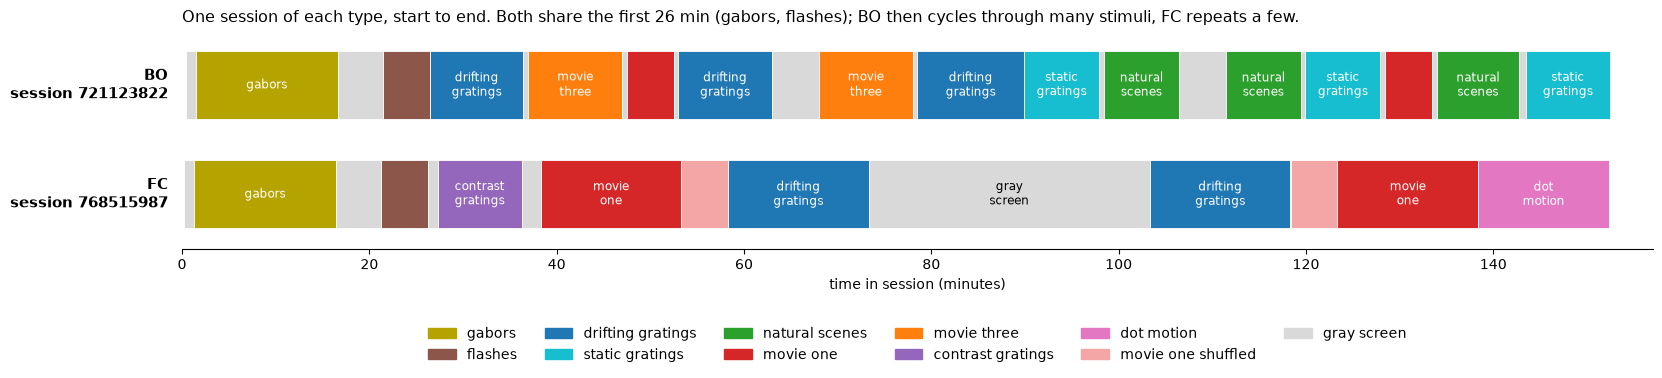

In [6]:
STIM_NAME = {
    "gabors": "gabors", "flashes": "flashes", "drifting_gratings": "drifting gratings",
    "drifting_gratings_75_repeats": "drifting gratings", "static_gratings": "static gratings",
    "natural_scenes": "natural scenes", "natural_movie_one": "movie one", "natural_movie_one_more_repeats": "movie one",
    "natural_movie_three": "movie three", "natural_movie_one_shuffled": "movie one shuffled",
    "drifting_gratings_contrast": "contrast gratings", "dot_motion": "dot motion", "spontaneous": "gray screen",
}


def stimulus_blocks(session_id):
    """Consecutive presentations of the same stimulus merged into one block, in minutes."""
    x = stimuli[stimuli.session_id == session_id].sort_values("start_time")
    run = (x.stimulus != x.stimulus.shift()).cumsum()
    b = x.groupby(run).agg(stim=("stimulus", "first"), t0=("start_time", "min"), t1=("stop_time", "max"))
    return b.assign(t0=b.t0 / 60, t1=b.t1 / 60)


bo = sessions[sessions.session_type == BO].session_id.iloc[0]
dot_dirs = stimuli[stimuli.stimulus == "dot_motion"].groupby("session_id").Dir.nunique()
fc = dot_dirs[dot_dirs == 4].index[0]

fig, ax = plt.subplots(figsize=(17, 4.2))
for y, (label, sid) in zip((1, 0), [("BO", bo), ("FC", fc)]):
    for b in stimulus_blocks(sid).itertuples():
        ax.barh(y, b.t1 - b.t0, left=b.t0, height=0.62, color=STIM_COLOR[b.stim], edgecolor="white", lw=0.6)
        if b.t1 - b.t0 >= 7.5:
            name = STIM_NAME[b.stim].replace(" ", "\n")
            dark = b.stim not in ("spontaneous", "natural_movie_one_shuffled")
            ax.text((b.t0 + b.t1) / 2, y, name, ha="center", va="center", fontsize=8.5, color="w" if dark else "k")
    ax.text(-1.5, y, f"{label}\nsession {sid}", ha="right", va="center", fontsize=11, fontweight="bold")
ax.set(xlim=(0, 157), ylim=(-0.5, 1.5), yticks=[], xlabel="time in session (minutes)")
for s in ("left", "right", "top"):
    ax.spines[s].set_visible(False)
shown = ["gabors", "flashes", "drifting_gratings", "static_gratings", "natural_scenes", "natural_movie_one",
         "natural_movie_three", "drifting_gratings_contrast", "dot_motion", "natural_movie_one_shuffled",
         "spontaneous"]
ax.legend([plt.Rectangle((0, 0), 1, 1, color=STIM_COLOR[k]) for k in shown], [STIM_NAME[k] for k in shown],
          loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=6, frameon=False, fontsize=10)
ax.set_title("One session of each type, start to end. Both share the first 26 min (gabors, flashes); BO then "
             "cycles through many stimuli, FC repeats a few.", fontsize=11.5, loc="left")
fig.subplots_adjust(left=0.125, right=0.99, top=0.88, bottom=0.36)
fig.savefig(FIGURE_DIR / "allen_session_timeline.png", dpi=150)
plt.show()

### Neurons per session

QC units per session (AllenSDK default), bars stacked by session type. All-unit counts, including the units
Allen labels noise, are in the per-session table above.

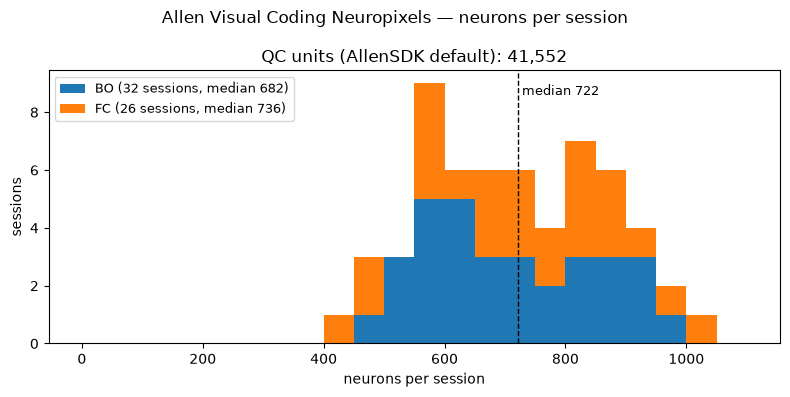

In [7]:
def half_up(x):
    return int(np.floor(x + 0.5))


def median_line(ax, values, color="k"):
    m = float(np.median(values))
    ax.axvline(m, color=color, ls="--", lw=1)
    ax.text(m, ax.get_ylim()[1] * 0.95, f" median {half_up(m):,}", color=color, va="top", fontsize=9)


fig, ax = plt.subplots(figsize=(8, 4))
groups = [sessions.loc[sessions.session_type == t, "qc_units"] for t in (BO, FC)]
ax.hist(groups, bins=np.arange(0, 1101, 50), stacked=True, color=[TYPE_COLOR[BO], TYPE_COLOR[FC]],
        label=[f"{SHORT[t]} ({len(g)} sessions, median {half_up(g.median())})" for t, g in zip((BO, FC), groups)])
ax.set(title=f"QC units (AllenSDK default): {sessions.qc_units.sum():,}", xlabel="neurons per session",
       ylabel="sessions")
median_line(ax, sessions.qc_units)
ax.legend(fontsize=9, loc="upper left")
fig.suptitle("Allen Visual Coding Neuropixels — neurons per session")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_neurons_per_session.png", dpi=150)
plt.show()

### Firing rates

One rate per QC unit (NWB `firing_rate`, spikes over the whole session), bars stacked by session type. The QC
presence-ratio cut removes most of the very low-rate units. Rates of all units (including noise) are in the
table below.

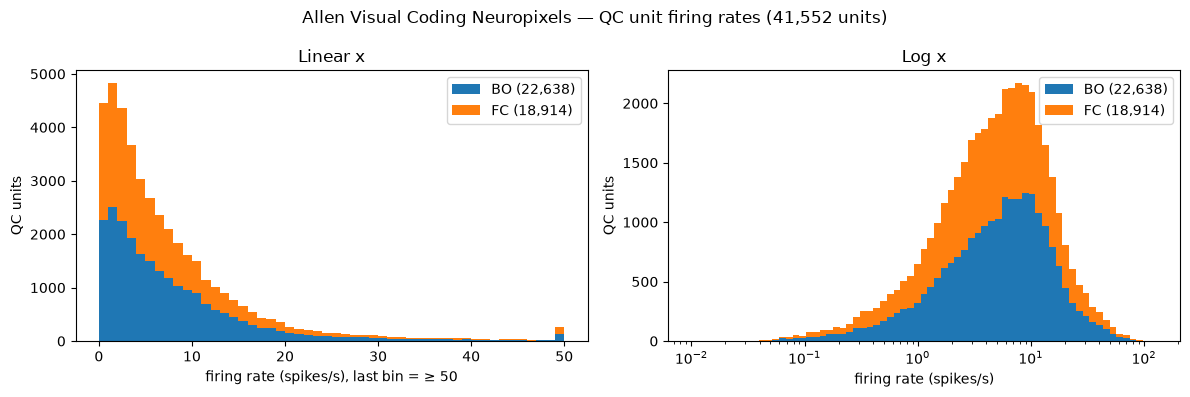

,units,mean Hz,median Hz
all all,136556.0,4.79,2.77
all BO,74658.0,4.93,2.93
all FC,61898.0,4.62,2.58
QC all,41552.0,7.72,5.15
QC BO,22638.0,7.93,5.52
QC FC,18914.0,7.47,4.76


In [8]:
fr = units.firing_rate
qc = {t: fr[units.qc & (units.type == t)] for t in (BO, FC)}
colors = [TYPE_COLOR[t] for t in qc]
labels = [f"{SHORT[t]} ({len(q):,})" for t, q in qc.items()]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.hist([q.clip(upper=50) for q in qc.values()], bins=np.arange(0, 51, 1), stacked=True, color=colors, label=labels)
ax.set(xlabel="firing rate (spikes/s), last bin = ≥ 50", ylabel="QC units", title="Linear x")
ax.legend()
ax = axes[1]
pos = [q[q > 0] for q in qc.values()]
bins = np.logspace(np.floor(np.log10(min(p.min() for p in pos))), np.log10(max(p.max() for p in pos)) + 0.05, 70)
ax.hist(pos, bins=bins, stacked=True, color=colors, label=labels)
ax.set_xscale("log")
ax.set(xlabel="firing rate (spikes/s)", ylabel="QC units", title="Log x")
ax.legend()
fig.suptitle(f"Allen Visual Coding Neuropixels — QC unit firing rates ({units.qc.sum():,} units)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_firing_rates.png", dpi=150)
plt.show()

display(pd.DataFrame({
    f"{name} {SHORT.get(t, 'all')}": {"units": int(m.sum()), "mean Hz": fr[m].mean(), "median Hz": fr[m].median()}
    for name, mask in [("all", fr.notna()), ("QC", units.qc)]
    for t, m in [("all", mask), (BO, mask & (units.type == BO)), (FC, mask & (units.type == FC))]
}).T.round(2))

### Trials by stimulus

Every session of a type runs the same fixed protocol (the only variations: 8 of the 32 BO sessions add a
drifting-gratings-contrast block, 2 FC sessions show dot motion in 8 directions instead of 4, and a few sessions
lose some presentations). So which stimuli a session has, and how many, is set by its type, and a table says it
better than a per-session plot.

- **conditions** — parameter combinations per session, e.g. drifting gratings: 8 directions × 5 temporal
  frequencies = 40, plus blank = 41. Blank (a gray screen in place of the stimulus) is its own condition, and
  one movie clip is one condition. Static-grating phase is not in the stimulus table, so its 4 phases come from
  the whitepaper: 6 orientations × 5 spatial frequencies × 4 phases + blank = 121.
- **repeats / condition** — median presentations of one condition per session; blank in brackets when it
  differs. Static gratings: the table's count per orientation × spatial frequency divided by the 4 phases (hence ~).
- **trials / session** — median [min – max] presentations per session (movies counted per repeat).
- **trial length** — median duration of one presentation.
- **min / session** — time the stimulus takes per session: first onset to last offset of each of its blocks,
  so the gray gaps between flashes, gratings and dots count. The 250 ms stimuli dominate the trial counts but
  not the time.

In [9]:
STIM_ORDER = ["flashes", "drifting_gratings", "drifting_gratings_contrast", "drifting_gratings_75_repeats",
              "static_gratings", "gabors", "dot_motion", "natural_scenes", "natural_movie_one",
              "natural_movie_one_more_repeats", "natural_movie_one_shuffled", "natural_movie_three", "spontaneous"]
STIM_LABEL = {
    "flashes": "flashes", "drifting_gratings": "drifting gratings", "drifting_gratings_contrast": "gratings × contrast",
    "drifting_gratings_75_repeats": "drifting gratings, 75 repeats", "static_gratings": "static gratings",
    "gabors": "gabors", "dot_motion": "dot motion", "natural_scenes": "natural scenes",
    "natural_movie_one": "natural movie one", "natural_movie_one_more_repeats": "natural movie one, more repeats",
    "natural_movie_one_shuffled": "natural movie one, shuffled", "natural_movie_three": "natural movie three",
    "spontaneous": "gray screen",
}
STIM_WHAT = {
    "flashes": "whole screen turns white or black",
    "drifting_gratings": "moving stripes; 8 directions × 5 temporal frequencies (1–15 Hz) + blank",
    "drifting_gratings_contrast": "moving stripes; 4 directions × 9 contrasts",
    "drifting_gratings_75_repeats": "moving stripes; 4 directions × 2 contrasts (80%, 10%) at 2 Hz",
    "static_gratings": "still stripes; 6 orientations × 5 spatial frequencies × 4 phases + blank",
    "gabors": "small striped patch; 9 × 9 grid of positions × 3 orientations (maps receptive fields)",
    "dot_motion": "field of moving dots; 4 directions × 7 speeds (2 sessions: 8 × 4 + blank)",
    "natural_scenes": "118 still photographs + blank",
    "natural_movie_one": "30 s black-and-white film clip (one trial = one full playthrough)",
    "natural_movie_one_more_repeats": "the same 30 s clip, more repeats",
    "natural_movie_one_shuffled": "the same clip with its frames in shuffled order",
    "natural_movie_three": "120 s film clip",
    "spontaneous": "gray screen, no stimulus (not a trial)",
}
assert set(stimuli.stimulus) == set(STIM_ORDER)

# A condition is one combination of stimulus parameters. Blank (a gray screen in place of the stimulus: every
# parameter empty, or frame -1 for natural scenes) is its own condition, and one movie clip is one condition.
PARAMS = ["orientation", "temporal_frequency", "spatial_frequency", "contrast", "color",
          "x_position", "y_position", "Dir", "Speed", "frame"]
PHASES = {"static_gratings": 4}  # static-grating phase is not in the table (whitepaper p. 17: 4 phases)
movie = stimuli.stimulus.str.startswith("natural_movie")
stimuli["blank"] = ~movie & stimuli[PARAMS[:-1]].isna().all(axis=1) & (stimuli.frame.isna() | (stimuli.frame == -1))
stimuli["condition"] = stimuli.groupby(["stimulus", *PARAMS], dropna=False).ngroup().where(~movie, -1)
stimuli["minutes"] = (stimuli.stop_time - stimuli.start_time) / 60

KEY = ["type", "stimulus", "session_id"]
per_session = stimuli.groupby(KEY).agg(trials=("minutes", "size"), trial_s=("minutes", lambda m: m.median() * 60))
# Time a stimulus takes: first onset to last offset of each of its blocks, so the gray gaps between flashes,
# gratings and dots count. Gray-screen rows are separate periods, so those are summed instead.
blocks = stimuli.groupby([*KEY, "block"]).agg(t0=("start_time", "min"), t1=("stop_time", "max"))
per_session["minutes"] = ((blocks.t1 - blocks.t0) / 60).groupby(KEY).sum()
spont = per_session.index.get_level_values("stimulus") == "spontaneous"
per_session.loc[spont, "minutes"] = stimuli.groupby(KEY).minutes.sum()[spont]

counts = stimuli.groupby([*KEY, "condition"]).agg(n=("blank", "size"), blank=("blank", "first")).reset_index()
counts["phases"] = counts.stimulus.map(PHASES).fillna(1)
full, blank = counts[~counts.blank], counts[counts.blank]
per_session["conditions"] = full.groupby(KEY).phases.sum().add(blank.groupby(KEY).size(), fill_value=0).astype(int)
per_session["repeats"] = full.assign(r=full.n / full.phases).groupby(KEY).r.median()
per_session["blank_repeats"] = blank.groupby(KEY).n.sum()
assert per_session.minutes.notna().all()
assert trial_stims.groupby("session_id").size().reindex(sessions.session_id).to_numpy().tolist() \
    == sessions.trials.tolist()


def usual(values, fmt="{:,.0f}"):
    """The value most sessions share, with the exceptions in brackets."""
    vc = values.value_counts()
    rest = [f"{n} sessions: {fmt.format(v)}" for v, n in vc.iloc[1:].items()]
    return fmt.format(vc.index[0]) + (f" ({'; '.join(rest)})" if rest else "")


def repeats_text(d, stim, unit=""):
    """Median repeats of one condition per session, e.g. "15 (blank 30)"; `unit` goes before the brackets."""
    text = ("~" if stim in PHASES else "") + f"{d.repeats.median():.0f}" + unit
    b = d.blank_repeats.median()
    return text + ("" if np.isnan(b) or b == d.repeats.median() else f" (blank {b:.0f})")


def stim_table(t):
    rows = []
    for stim in STIM_ORDER:
        if (t, stim) not in per_session.index.droplevel(2):
            continue
        d = per_session.loc[(t, stim)]
        n = d.trials
        trial = stim != "spontaneous"
        rows.append({
            "stimulus": stim, "what": STIM_WHAT[stim], "sessions": len(d),
            "conditions": usual(d.conditions) if trial else "—",
            "repeats / condition": repeats_text(d, stim) if trial else "—",
            "trials / session": f"{n.median():,.0f}" + ("" if n.min() == n.max() else f" [{n.min():,} – {n.max():,}]")
                                if trial else "—",
            "trial length (s)": f"{d.trial_s.median():.2f}" if trial else "—",
            "min / session": round(d.minutes.median(), 1),
        })
    return pd.DataFrame(rows).set_index("stimulus")


for t in (BO, FC):
    print(f"{SHORT[t]}: {t} ({(sessions.session_type == t).sum()} sessions)")
    display(stim_table(t))

BO: brain_observatory_1.1 (32 sessions)


,what,sessions,conditions,repeats / condition,trials / session,trial length (s),min / session
stimulus,,,,,,,
flashes,whole screen turns white or black,32,2,75,150,0.25,5.0
drifting_gratings,moving stripes; 8 directions × 5 temporal frequencies (1–15 Hz) + blank,32,41,15 (blank 30),630 [628 – 630],2.00,31.5
drifting_gratings_contrast,moving stripes; 4 directions × 9 contrasts,8,36,15,540,0.50,9.0
static_gratings,still stripes; 6 orientations × 5 spatial frequencies × 4 phases + blank,32,121,~48 (blank 194),"6,000",0.25,25.0
gabors,small striped patch; 9 × 9 grid of positions × 3 orientations (maps receptive fields),32,243,15,"3,645",0.25,15.2
natural_scenes,118 still photographs + blank,32,119,50,"5,950",0.25,24.8
natural_movie_one,30 s black-and-white film clip (one trial = one full playthrough),32,1,20,20,30.03,10.0
natural_movie_three,120 s film clip,32,1,10,10,120.10,20.0
spontaneous,"gray screen, no stimulus (not a trial)",32,—,—,—,—,20.6


FC: functional_connectivity (26 sessions)


,what,sessions,conditions,repeats / condition,trials / session,trial length (s),min / session
stimulus,,,,,,,
flashes,whole screen turns white or black,26,2,75,150,0.25,5.0
drifting_gratings_contrast,moving stripes; 4 directions × 9 contrasts,26,36,15,540,0.50,9.0
drifting_gratings_75_repeats,"moving stripes; 4 directions × 2 contrasts (80%, 10%) at 2 Hz",26,8,75,600,2.00,30.0
gabors,small striped patch; 9 × 9 grid of positions × 3 orientations (maps receptive fields),26,243,15,"3,645",0.25,15.2
dot_motion,field of moving dots; 4 directions × 7 speeds (2 sessions: 8 × 4 + blank),26,28 (2 sessions: 33),15,420 [420 – 495],1.00,14.0
natural_movie_one_more_repeats,"the same 30 s clip, more repeats",26,1,60,60,30.03,30.0
natural_movie_one_shuffled,the same clip with its frames in shuffled order,26,1,20,20,30.03,10.0
spontaneous,"gray screen, no stimulus (not a trial)",26,—,—,—,—,38.9


### Conditions × repeats

One point per stimulus: conditions per session (x) against repeats of each condition per session (y), log
scales. Dotted diagonals mark trials per session (conditions × repeats). Gray = shown the same way in both
types (gabors and flashes open every session; gratings × contrast runs in every FC session and 8 of the 32 BO
sessions). Across the dataset, multiply the repeats by the sessions that show the stimulus.

BO spreads its trials over many conditions with few repeats each; FC trades conditions for repeats (drifting
gratings: 41 × 15 in BO against 8 × 75 in FC; movie one: 20 against 60 repeats).

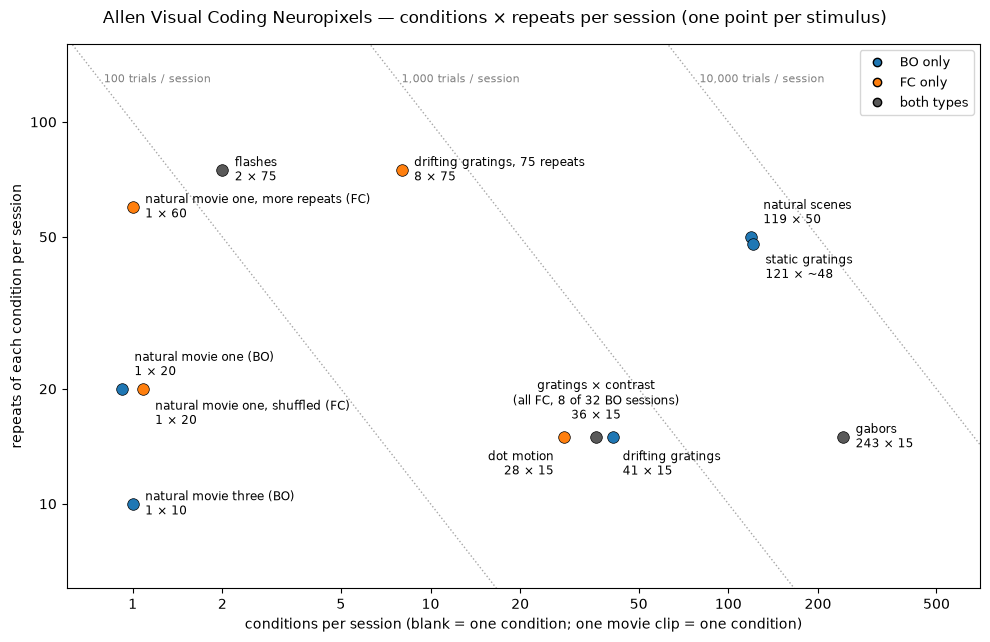

In [10]:
pts = (per_session.drop(index="spontaneous", level="stimulus").groupby(["type", "stimulus"])
       .agg(conditions=("conditions", lambda c: c.mode().iloc[0]), repeats=("repeats", "median")).reset_index())
pts["repeats"] = pts.repeats.round()
# A stimulus shown the same way in both types becomes one gray point.
pts["both"] = pts.groupby(["stimulus", "conditions", "repeats"]).type.transform("nunique") == 2
pts = pts.drop_duplicates(["stimulus", "conditions", "repeats"]).reset_index(drop=True)
pts["color"] = np.where(pts.both, "0.35", pts.type.map(TYPE_COLOR))
# Different stimuli at the same point sit side by side.
same = pts.groupby(["conditions", "repeats"]).cumcount()
pts["x"] = pts.conditions * np.where(pts.duplicated(["conditions", "repeats"], keep=False), 0.92 + 0.16 * same, 1)
LABEL_AT = {  # text offset in points; the side sets the alignment
    "gabors": (9, 0), "natural_scenes": (9, 7), "static_gratings": (9, -7), "drifting_gratings": (7, -9),
    "drifting_gratings_contrast": (0, 10), "dot_motion": (-7, -9), "drifting_gratings_75_repeats": (9, 0),
    "flashes": (9, 0), "natural_movie_one": (9, 7), "natural_movie_one_shuffled": (9, -7),
    "natural_movie_three": (9, 0), "natural_movie_one_more_repeats": (9, 0),
}
assert set(pts.stimulus) == set(LABEL_AT)

fig, ax = plt.subplots(figsize=(10, 6.5))
xs = np.logspace(np.log10(0.5), np.log10(700), 50)
for total in (100, 1_000, 10_000):
    ax.plot(xs, total / xs, ls=":", color="0.65", lw=1, zorder=0)
    ax.text(total / 125, 125, f"{total:,} trials / session", color="0.5", fontsize=8, ha="left", va="bottom")
for p in pts.itertuples():
    ax.scatter(p.x, p.repeats, s=70, color=p.color, edgecolor="k", lw=0.5, zorder=3)
    dx, dy = LABEL_AT[p.stimulus]
    name = STIM_LABEL[p.stimulus] + ("\n(all FC, 8 of 32 BO sessions)" if p.stimulus == "drifting_gratings_contrast"
                                     else f" ({SHORT[p.type]})" if not p.both and p.stimulus.startswith("natural_movie")
                                     else "")
    reps = ("~" if p.stimulus in PHASES else "") + f"{p.repeats:.0f}"
    ax.annotate(f"{name}\n{p.conditions} × {reps}", (p.x, p.repeats), xytext=(dx, dy), textcoords="offset points",
                ha="left" if dx > 0 else "right" if dx < 0 else "center",
                va="center" if dy == 0 else "bottom" if dy > 0 else "top", fontsize=8.5)
ticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]
ax.set(xscale="log", yscale="log", xlim=(0.6, 700), ylim=(6, 160), xticks=ticks, xticklabels=ticks,
       yticks=[10, 20, 50, 100], yticklabels=[10, 20, 50, 100],
       xlabel="conditions per session (blank = one condition; one movie clip = one condition)",
       ylabel="repeats of each condition per session")
ax.minorticks_off()
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", color=c, markeredgecolor="k", label=l) for c, l in
                   [(TYPE_COLOR[BO], "BO only"), (TYPE_COLOR[FC], "FC only"), ("0.35", "both types")]],
          loc="upper right", fontsize=9)
fig.suptitle("Allen Visual Coding Neuropixels — conditions × repeats per session (one point per stimulus)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_conditions_x_repeats.png", dpi=150)
plt.show()

### Trials per session

One dot per session. Trial counts are fixed by the protocol, so each type has one main count, and the smaller
columns are labeled with their cause. The panels have different x ranges: a BO session has about 3× the trials
of an FC session.

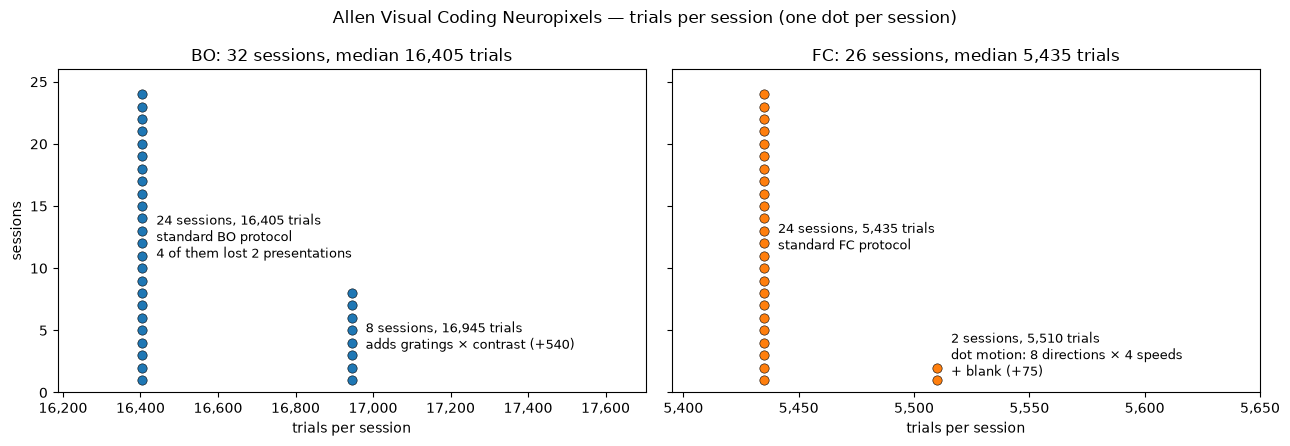

In [11]:
dot_dirs = stimuli[stimuli.stimulus == "dot_motion"].groupby("session_id").Dir.nunique()
contrast_ids = set(stimuli.session_id[(stimuli.stimulus == "drifting_gratings_contrast") & (stimuli.type == BO)])
CAUSE = {  # why a session's trial count differs from the rest of its type
    BO: lambda sid: "adds gratings × contrast (+540)" if sid in contrast_ids else "standard BO protocol",
    FC: lambda sid: "dot motion: 8 directions × 4 speeds\n+ blank (+75)" if dot_dirs.get(sid) == 8
                    else "standard FC protocol",
}
by_cause = sessions.assign(cause=[CAUSE[t](sid) for t, sid in zip(sessions.session_type, sessions.session_id)])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, t in zip(axes, (BO, FC)):
    d = by_cause[by_cause.session_type == t]
    for cause, g in d.groupby("cause"):
        x = g.trials.max()
        ax.scatter(np.full(len(g), x), np.arange(1, len(g) + 1), s=45, color=TYPE_COLOR[t], edgecolor="k", lw=0.4)
        lost = (x - g.trials[g.trials < x]).unique()
        note = f"\n{(g.trials < x).sum()} of them lost {', '.join(map(str, sorted(lost)))} presentations" if len(lost) else ""
        ax.annotate(f"{len(g)} sessions, {x:,} trials\n{cause}{note}", (x, max(len(g) / 2 + 0.5, 3)),
                    xytext=(10, 0), textcoords="offset points", va="center", fontsize=9)
    lo, hi = d.trials.min(), d.trials.max()
    w = max(hi - lo, 100)
    ax.set(xlim=(lo - 0.4 * w, hi + 1.4 * w), xlabel="trials per session",
           title=f"{SHORT[t]}: {len(d)} sessions, median {half_up(d.trials.median()):,} trials")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axes[0].set(ylabel="sessions", ylim=(0, 26))
fig.suptitle("Allen Visual Coding Neuropixels — trials per session (one dot per session)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_trials_per_session.png", dpi=150)
plt.show()

### Brain regions

Units per structure (CCF acronym of each unit's peak channel), top 30 by unit count. `grey` = in the brain
but not assigned to a structure; blank = the unit's peak channel has no structure label (a few units on many probes, mostly near the top of
the shank; no probe is entirely blank).

The probes are aimed at the visual system, so most units are in visual cortex, the hippocampus below it,
and the thalamus below that:

| Group | Acronyms in the figure |
|---|---|
| Visual cortex | VISp primary visual; VISl lateral, VISli laterointermediate, VISal anterolateral, VISrl rostrolateral, VISam anteromedial, VISpm posteromedial, VISmma mediomedial anterior (higher visual areas); VIS = visual cortex, area not resolved |
| Hippocampus | CA1, CA3, DG dentate gyrus, SUB subiculum, ProS prosubiculum |
| Visual thalamus | LGd dorsal lateral geniculate (retina → cortex relay), LGv ventral lateral geniculate, LP lateral posterior (mouse pulvinar), POL posterior limiting nucleus |
| Other thalamus | TH thalamus (unresolved), VPM ventral posteromedial (whiskers), PO posterior complex, MGv / MGd medial geniculate (auditory), SGN suprageniculate, Eth ethmoid |
| Midbrain | APN anterior pretectal nucleus, NOT nucleus of the optic tract, MB midbrain (unresolved) |

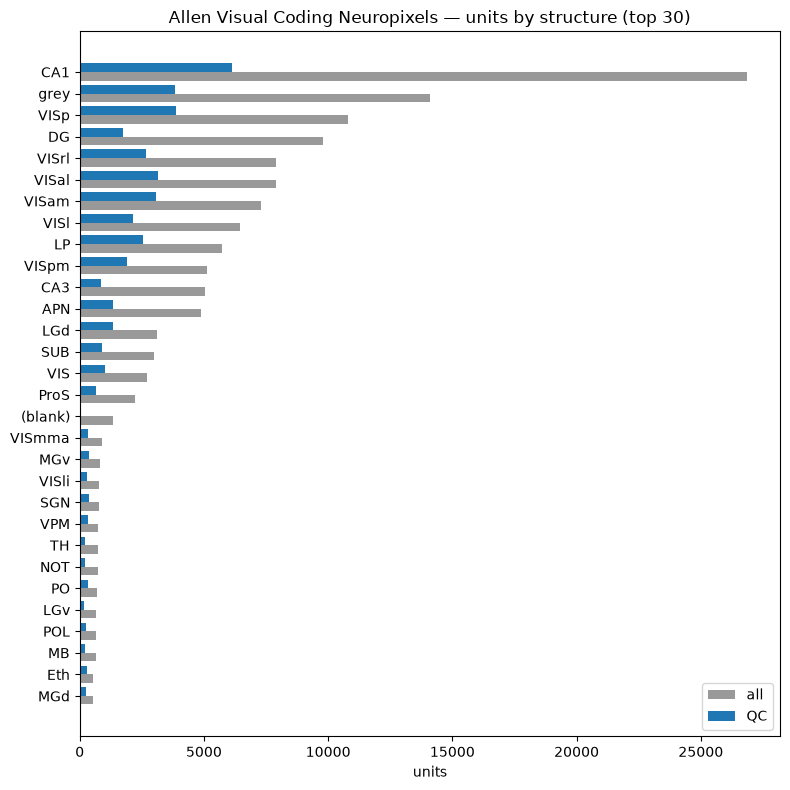

61 structures; visual cortex (VIS*) 50,211 units (18,534 QC)


In [12]:
region = units.region.replace("", "(blank)")
reg = pd.DataFrame({"all": region.value_counts(), "QC": region[units.qc].value_counts()}).fillna(0).astype(int)
reg = reg.sort_values("all").tail(30)
fig, ax = plt.subplots(figsize=(8, 8))
y = np.arange(len(reg))
ax.barh(y - 0.2, reg["all"], height=0.4, color="0.6", label="all")
ax.barh(y + 0.2, reg["QC"], height=0.4, color="C0", label="QC")
ax.set(yticks=y, yticklabels=reg.index, xlabel="units",
       title="Allen Visual Coding Neuropixels — units by structure (top 30)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_regions.png", dpi=150)
plt.show()
visual = units.region.str.startswith("VIS")
print(f"{units.region.nunique()} structures; visual cortex (VIS*) {visual.sum():,} units ({visual[units.qc].sum():,} QC)")

### Raster

An example BO session near the middle of the unit counts (739448407: 647 QC units; the BO median is 682), 30 s starting 5 s before its first flash. Rows = QC units, grouped by
probe and sorted by depth (tip at the bottom).

- **Shaded bands** — 250 ms full-field flashes, one every 2 s: yellow = screen turns white, purple = screen
  turns black. Before the first flash (0–5 s) the screen is gray. Each flash is one trial.
- **Blue horizontal lines** — boundaries between probes (probe names on the right). Each probe is a separate
  shank in a different part of the visual system, recorded at the same time.

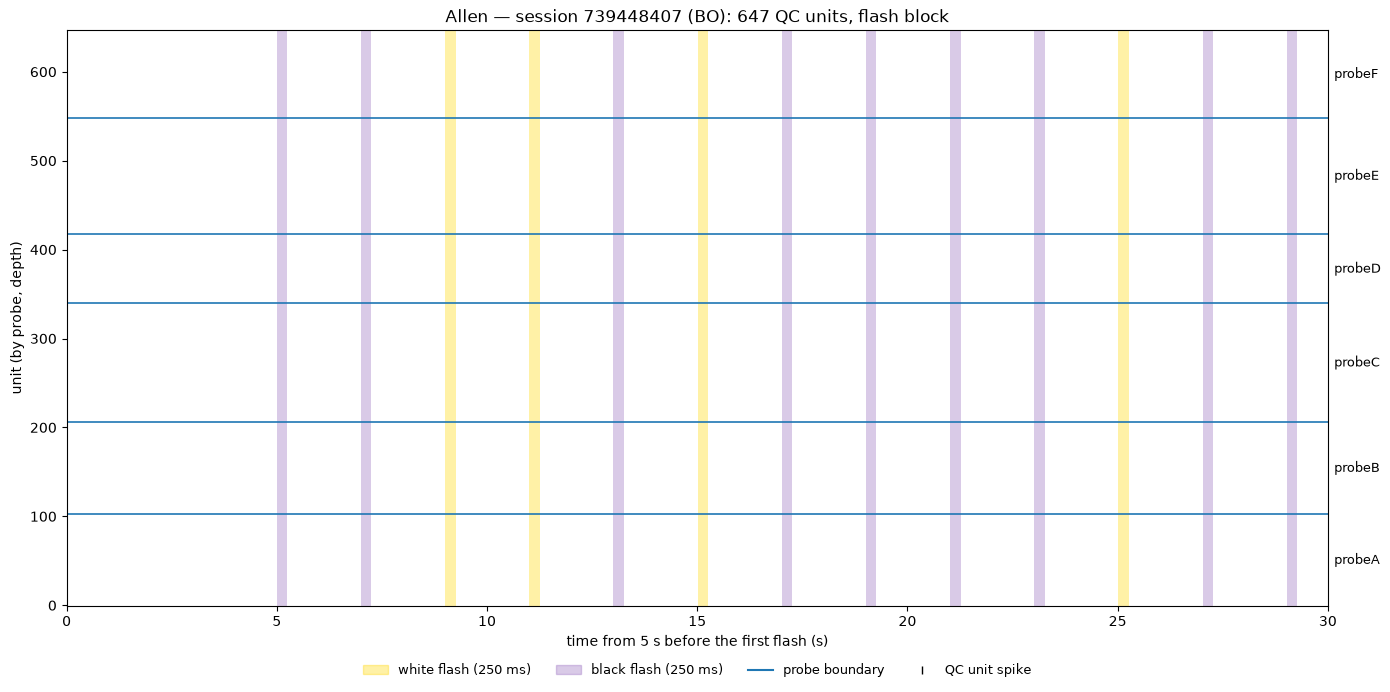

In [13]:
r = np.load(TABLES / "raster.npz")
sid = int(r["session_id"])
s = sessions.set_index("session_id").loc[sid]
u = units[units.session_id == sid].reset_index(drop=True)
assert (u.unit_id.to_numpy() == r["unit_id"]).all()
u["nwb_row"] = np.arange(len(u))
shown = u[u.qc].sort_values(["probe", "depth_um"]).reset_index(drop=True)
shown["row"] = np.arange(len(shown))
spk = pd.DataFrame({"nwb_row": r["unit_row"], "t": r["times"]}).merge(
    shown[["nwb_row", "row"]], on="nwb_row", how="inner")

fig, ax = plt.subplots(figsize=(14, 7))
for on, color in zip(r["flash_on"], r["flash_color"]):
    ax.axvspan(on, on + 0.25, color="gold" if color > 0 else "C4", alpha=0.35, lw=0)
ax.scatter(spk.t, spk.row, s=0.3, color="k", marker="|", linewidths=0.4, rasterized=True)
for p, grp in shown.groupby("probe"):
    if grp.row.max() < len(shown) - 1:
        ax.axhline(grp.row.max() + 0.5, color="C0", lw=1.2)
    ax.text(float(r["window_s"]) * 1.005, grp.row.mean(), p, va="center", fontsize=9)
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="gold", alpha=0.35, label="white flash (250 ms)"),
    plt.Rectangle((0, 0), 1, 1, color="C4", alpha=0.35, label="black flash (250 ms)"),
    plt.Line2D([], [], color="C0", lw=1.5, label="probe boundary"),
    plt.Line2D([], [], color="k", marker="|", ls="", label="QC unit spike"),
], loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=9, frameon=False)
ax.set(xlim=(0, float(r["window_s"])), ylim=(-0.5, len(shown) - 0.5),
       xlabel="time from 5 s before the first flash (s)", ylabel="unit (by probe, depth)",
       title=f"Allen — session {sid} ({SHORT[s.session_type]}): {len(shown):,} QC units, flash block")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "allen_raster.png", dpi=150)
plt.show()

## 4. Which sessions the draft uses

Draft Table 8 has four Allen splits: BO drifting one TF (959 neurons, 120 trials), Flash BO top (959, 150),
Flash FC second (930, 150) and Flash FC top (1,005, 150). 120 = 8 directions × 15 repeats at one temporal
frequency, and 150 = one session's flash block.

The run that produced them does not record session IDs. **top** / **second** match ranking sessions by QC
unit count: the top sessions are BO 757216464 (984 QC units), FC 794812542 (1,036) and FC 771160300 (971).
Dropping units that are nearly silent during the flash block (≥ 17 spikes in the 150 × 2 s flash trials,
about 0.06 Hz) lands within 5 units of all three draft counts. The exact rule is not recoverable, but
the sessions are clear.

In [14]:
w = pd.read_parquet(TABLES / "draft_window_counts.parquet")
draft = {"Flash BO top": (757216464, 959), "Flash FC top": (794812542, 1005), "Flash FC second": (771160300, 930)}
display(pd.DataFrame([
    {"split": k, "session_id": sid, "draft neurons": n,
     "QC units": int((w.session_id == sid).sum()),
     "QC & ≥ 17 flash spikes": int(((w.session_id == sid) & (w.flash_spikes >= 17)).sum()),
     "session rank by QC (within type)": int(sessions[sessions.session_type == session_type[sid]]
                                             .qc_units.rank(ascending=False, method="min")
                                             [sessions.session_id == sid].iloc[0])}
    for k, (sid, n) in draft.items()
]))

,split,session_id,draft neurons,QC units,QC & ≥ 17 flash spikes,session rank by QC (within type)
0,Flash BO top,757216464,959,984,959,1
1,Flash FC top,794812542,1005,1036,1010,1
2,Flash FC second,771160300,930,971,931,2


## Spreadsheet

- Same columns as the NLB / FALCON / IBL CSVs. One totals row per session type, then one row per stimulus of
  that type. CHANNELS = `N/A` (sorted units).
- Stimulus rows: SUBJECTS = sessions that show it; TRIALS = its presentations; NEURONS = QC units of those
  sessions (every unit is recorded through the whole session); LENGTH = its time, as in the trials table; RAW is
  left blank (one NWB holds a whole session); NOTES = its conditions.
- Stimulus-row BENCHMARK is an estimate: each session's QC-unit build (spikes, non-spike NWB data, metric CSVs)
  scaled by the stimulus's share of the recording, plus the templates it shows. The exact split needs spike
  counts per stimulus window, which the tables do not hold.
- Length: 1 decimal minute. RAW / BENCHMARK: 3 decimal GB.
- This cell writes `tutorials/allen_datasets.csv`.

In [15]:
templates = bucket[bucket.kind == "templates"]
template_gb = {
    BO: templates.bytes.sum() / GB,  # natural scenes + movies one and three
    FC: templates.bytes[templates.key.str.endswith("natural_movie_1.h5")].sum() / GB,
}
TEMPLATE_KEY = {  # template files each stimulus shows
    "natural_scenes": "natural_scene_templates/", "natural_movie_one": "natural_movie_1.h5",
    "natural_movie_one_more_repeats": "natural_movie_1.h5", "natural_movie_one_shuffled": "natural_movie_1.h5",
    "natural_movie_three": "natural_movie_3.h5",
}
store = storage.set_index("session_id")
store["type"] = session_type
bytes_per_spike = store.spike_times.sum() / sessions.spikes.sum()
qc_spikes = units[units.qc].groupby("session_id").spike_count.sum()
store["qc_spike_bytes"] = qc_spikes.reindex(store.index).fillna(0) * bytes_per_spike
store["benchmark"] = store.qc_spike_bytes + store.other
metric_bytes = bucket[bucket.kind == "session_metrics"].groupby("session_id").bytes.sum()
store["build"] = store.benchmark + metric_bytes.reindex(store.index).fillna(0)  # per-session part of the build
by_session = sessions.set_index("session_id")


def stimulus_row(t, stim):
    d = per_session.loc[(t, stim)]
    ids = d.index
    share = d.minutes * 60 / by_session.recording_s[ids]
    template = templates.bytes[templates.key.str.contains(TEMPLATE_KEY[stim], regex=False)].sum() \
        if stim in TEMPLATE_KEY else 0
    q = by_session.qc_units[ids]
    return {
        "DATASET": f"Allen VCN {SHORT[t]}: {STIM_LABEL[stim]}",
        "ANIMAL": "Mouse",
        "SUBJECTS": len(ids),
        "TRIALS": int(d.trials.sum()),
        "TOTAL CHANNELS": "N/A",
        "MEDIAN CHANNELS": "N/A",
        "TOTAL NEURONS": int(q.sum()),
        "MEDIAN NEURONS": half_up(q.median()),
        "RECORDING LENGTH (min)": round(d.minutes.sum(), 1),
        "RAW DATASET SIZE (GB)": "",
        "BENCHMARK DATASET SIZE (GB)": round(((store.build[ids] * share).sum() + template) / GB, 3),
        "NOTES": f"{STIM_WHAT[stim]}. Per session: {usual(d.conditions)} condition{'s' * bool(d.conditions.max() > 1)} × "
                 f"{repeats_text(d, stim, ' repeats')}, {d.trial_s.median():.3g} s each. Benchmark size is an estimate: "
                 f"each session's build × this block's share of the recording, plus the stimulus templates it shows.",
        "BASIC STATS": "",
    }


rows = []
for t, name in [(BO, "Allen VCN Brain Observatory"), (FC, "Allen VCN Functional Connectivity")]:
    s, u, b = sessions[sessions.session_type == t], units[units.type == t], bucket[bucket.type == t]
    st = trial_stims[trial_stims.type == t].stimulus.value_counts().reindex(STIM_ORDER).dropna().astype(int)
    stim_text = ", ".join(f"{k} {v:,}" for k, v in st.items())
    fr_t, fr_tq = u.firing_rate, u.firing_rate[u.qc]
    raw_gb = b.bytes.sum() / GB
    bench_gb = store.build[store.type == t].sum() / GB + template_gb[t]
    draft_note = ("Draft Table 8 (inferred; the draft's unit rule and session IDs are not recorded): Flash BO top is most likely session 757216464, the BO session with the most QC units; BO drifting one TF has the same 959 neurons, so presumably the same session."
                  if t == BO else
                  "Draft Table 8 (inferred; the draft's unit rule and session IDs are not recorded): Flash FC top and second are most likely sessions 794812542 and 771160300, the FC sessions with the most QC units.")
    notes = (
        f"Allen Brain Observatory Visual Coding Neuropixels, {SHORT[t]} session type: {len(s)} sessions, one per mouse "
        f"({s.genotype.eq('wt/wt').sum()} wild type, {(~s.genotype.eq('wt/wt')).sum()} Cre;Ai32 opto-tagging lines); "
        f"passive viewing, head-fixed on a running wheel; {int(s.probes.sum())} Neuropixels 1.0 probes "
        f"({int(s.probes.min())}–{int(s.probes.max())} per session); CHANNELS N/A because units are sorted (Kilosort2). "
        f"NEURONS = AllenSDK default QC units (not noise & ISI violations < 0.5 & amplitude cutoff < 0.1 & "
        f"presence ratio > 0.9); all NWB units {len(u):,} (median {half_up(s.units.median())}/session). "
        f"TRIALS = stimulus presentations, movies counted per repeat, spontaneous excluded: {stim_text}. "
        f"LENGTH = first-to-last spike per session, summed ({s.recording_s.sum() / 3600:,.1f} h). "
        f"RAW = bucket files for these sessions: session NWBs {b.bytes[b.kind == 'session_nwb'].sum() / GB:.1f} GB + "
        f"LFP {b.bytes[b.kind == 'lfp'].sum() / GB:.1f} GB + unit metric CSVs {b.bytes[b.kind == 'session_metrics'].sum() / GB:.3f} GB "
        f"(no raw 30 kHz voltage is public). "
        f"BENCHMARK = QC-unit spike times ({store.qc_spike_bytes[store.type == t].sum() / GB:.1f} GB) + NWB stimulus "
        f"tables, unit metadata, running and eye tracking (eye tracking in {int(s.has_eye_tracking.sum())} of {len(s)} sessions; "
        f"{store.other[store.type == t].sum() / GB:.1f} GB) + unit metric CSVs and stimulus templates "
        f"({(b.bytes[b.kind == 'session_metrics'].sum() / GB + template_gb[t]):.2f} GB); per-spike amplitudes and mean waveforms dropped; "
        f"all-unit spike times would be {store.spike_times[store.type == t].sum() / GB:.1f} GB. " + draft_note
    )
    rows.append({
        "DATASET": name,
        "ANIMAL": "Mouse",
        "SUBJECTS": s.specimen_id.nunique(),
        "TRIALS": int(s.trials.sum()),
        "TOTAL CHANNELS": "N/A",
        "MEDIAN CHANNELS": "N/A",
        "TOTAL NEURONS": int(s.qc_units.sum()),
        "MEDIAN NEURONS": half_up(s.qc_units.median()),
        "RECORDING LENGTH (min)": round(s.recording_s.sum() / 60, 1),
        "RAW DATASET SIZE (GB)": round(raw_gb, 3),
        "BENCHMARK DATASET SIZE (GB)": round(bench_gb, 3),
        "NOTES": notes,
        "BASIC STATS": (f"QC-unit firing rate: mean {fr_tq.mean():.2f}, median {fr_tq.median():.2f} spikes/s "
                        f"(all units: mean {fr_t.mean():.2f}, median {fr_t.median():.2f})"),
    })
    rows += [stimulus_row(t, stim) for stim in STIM_ORDER[:-1] if (t, stim) in per_session.index.droplevel(2)]
inventory = pd.DataFrame(rows)
assert inventory.groupby(inventory.DATASET.str.contains(":")).TRIALS.sum().nunique() == 1  # stimulus rows add up
display(inventory.drop(columns=["NOTES", "BASIC STATS"]).set_index("DATASET"))
for n in inventory.NOTES:
    print(n, "\n")
csv_path = REPO / "tutorials" / "allen_datasets.csv"
inventory.to_csv(csv_path, index=False)
print("wrote", csv_path)

,ANIMAL,SUBJECTS,TRIALS,TOTAL CHANNELS,MEDIAN CHANNELS,TOTAL NEURONS,MEDIAN NEURONS,RECORDING LENGTH (min),RAW DATASET SIZE (GB),BENCHMARK DATASET SIZE (GB)
DATASET,,,,,,,,,,
Allen VCN Brain Observatory,Mouse,32,529272,N/A,N/A,22638,682,5242.0,477.616,18.927
Allen VCN BO: flashes,Mouse,32,4800,N/A,N/A,22638,682,159.2,,0.545
Allen VCN BO: drifting gratings,Mouse,32,20152,N/A,N/A,22638,682,1006.8,,3.448
Allen VCN BO: gratings × contrast,Mouse,8,4320,N/A,N/A,5343,641,72.0,,0.246
Allen VCN BO: static gratings,Mouse,32,192000,N/A,N/A,22638,682,800.7,,2.742
Allen VCN BO: gabors,Mouse,32,116640,N/A,N/A,22638,682,486.4,,1.666
Allen VCN BO: natural scenes,Mouse,32,190400,N/A,N/A,22638,682,794.0,,2.846
Allen VCN BO: natural movie one,Mouse,32,640,N/A,N/A,22638,682,320.3,,1.263
Allen VCN BO: natural movie three,Mouse,32,320,N/A,N/A,22638,682,640.5,,2.859


Allen Brain Observatory Visual Coding Neuropixels, BO session type: 32 sessions, one per mouse (16 wild type, 16 Cre;Ai32 opto-tagging lines); passive viewing, head-fixed on a running wheel; 183 Neuropixels 1.0 probes (4–6 per session); CHANNELS N/A because units are sorted (Kilosort2). NEURONS = AllenSDK default QC units (not noise & ISI violations < 0.5 & amplitude cutoff < 0.1 & presence ratio > 0.9); all NWB units 74,658 (median 2292/session). TRIALS = stimulus presentations, movies counted per repeat, spontaneous excluded: flashes 4,800, drifting_gratings 20,152, drifting_gratings_contrast 4,320, static_gratings 192,000, gabors 116,640, natural_scenes 190,400, natural_movie_one 640, natural_movie_three 320. LENGTH = first-to-last spike per session, summed (87.4 h). RAW = bucket files for these sessions: session NWBs 80.5 GB + LFP 397.1 GB + unit metric CSVs 0.053 GB (no raw 30 kHz voltage is public). BENCHMARK = QC-unit spike times (14.0 GB) + NWB stimulus tables, unit metadata, r